# Interactive Visualization Setup

### Imports/Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
final_topic_frame_df = pd.read_parquet('merged_topic_and_frames_filtered_with_time_and_frames.parquet')

In [4]:
# Pull out mapping of frame indices to names

frame_mapping = {}

for idx, row in final_topic_frame_df.iterrows():
    frames = row['frames']
    vector = row['vector']
    
    # Convert arrays
    if isinstance(frames, np.ndarray):
        frames = frames.tolist()
    if isinstance(vector, np.ndarray):
        vector = vector.tolist()
    
    # Run through
    frame_idx = 0
    for i, val in enumerate(vector):
        if val == 1:
            frame_mapping[i] = frames[frame_idx]
            frame_idx += 1

# Get list and map
ordered_frame_names = [frame_mapping[i] for i in sorted(frame_mapping.keys())]


In [48]:
# Add column to df with clean names for viz

clean_names = {
    'cap&res': 'Capacity & Resources',
    'crime': 'Crime',
    'culture': 'Culture',
    'economic': 'Economic',
    'fairness': 'Fairness',
    'health': 'Health',
    'legality': 'Legality',
    'morality': 'Morality',
    'policy': 'Policy',
    'political': 'Political',
    'public_op': 'Public Opinion',
    'quality_life': 'Quality of Life',
    'regulation': 'Regulation',
    'security': 'Security'
}

final_topic_frame_df['frames_clean'] = final_topic_frame_df['frames'].apply(
    lambda x: [clean_names.get(frame, frame.title()) for frame in x] if isinstance(x, (list, np.ndarray)) else x
)

final_topic_frame_df['quarter_clean'] = final_topic_frame_df['quarter'].apply(
    lambda x: f"Q{str(x)[-1]} {str(x)[:4]}"
)

In [ ]:
# Separate dataframes by bias group

def group_bias(bias):
    if bias in ['Left', 'Lean Left']:
        return 'Left'
    elif bias in ['Right', 'Lean Right']:
        return 'Right'
    else:
        return 'Center'

final_topic_frame_df['bias_grouped'] = final_topic_frame_df['bias'].apply(group_bias)

left_df = final_topic_frame_df[final_topic_frame_df['bias_grouped'] == 'Left']
center_df = final_topic_frame_df[final_topic_frame_df['bias_grouped'] == 'Center']
right_df = final_topic_frame_df[final_topic_frame_df['bias_grouped'] == 'Right']

# pulled colors from GOP & DNC official websites
color_map = {
        'Left': '#0044C9',
        'Center': '#808080',
        'Right': '#D71F28'
    }

### Base Visualizations

#### Frame Co-Occurence Rates

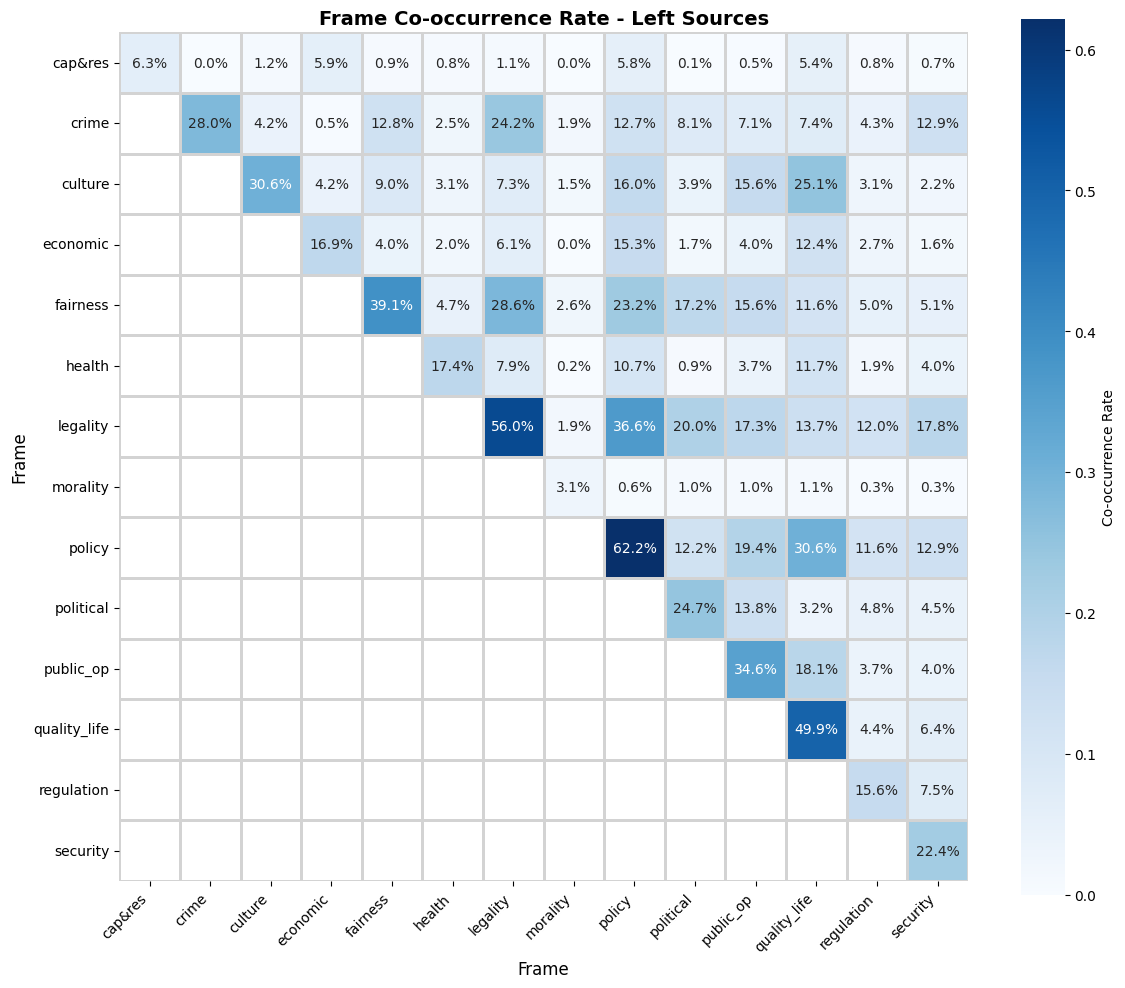

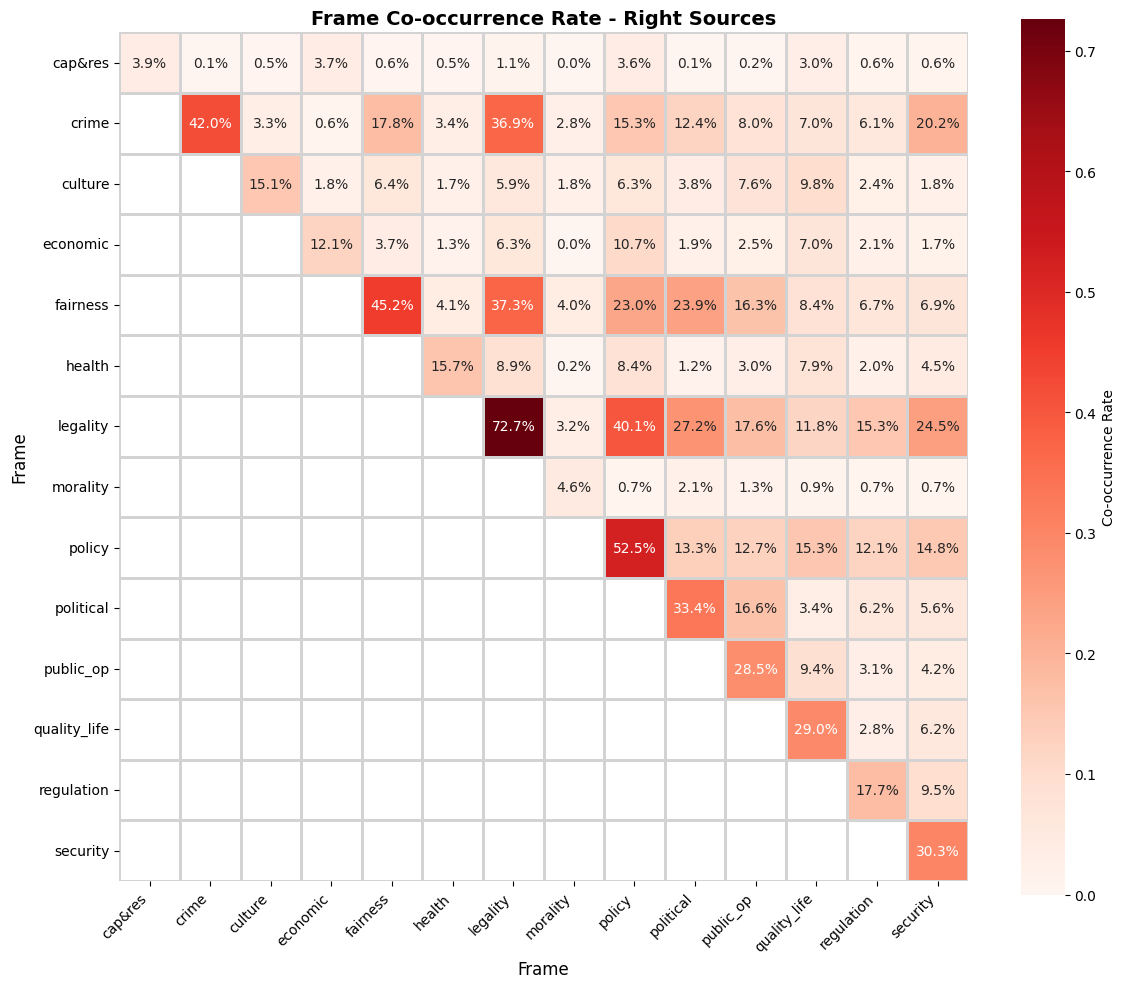

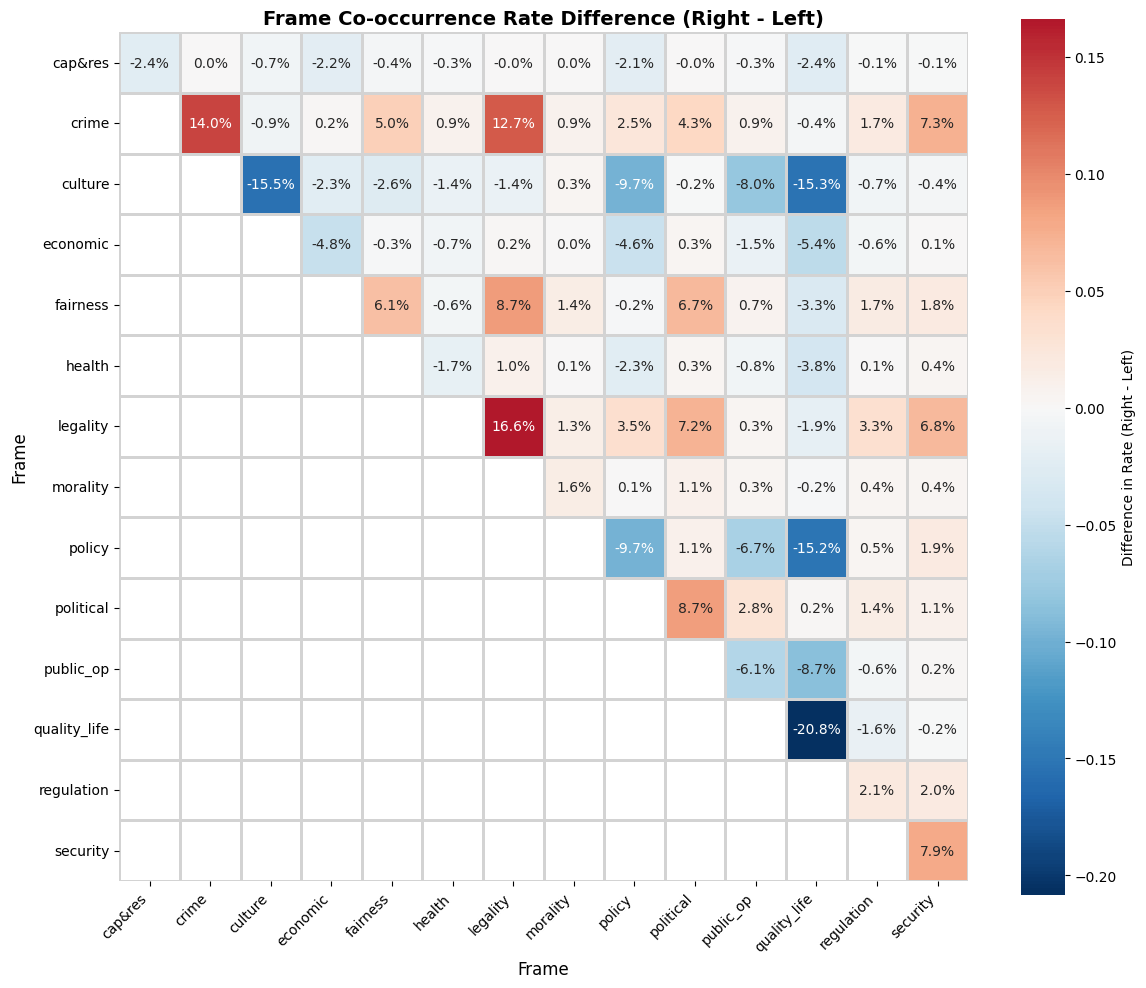

In [66]:
# for each frame, distribution of the "other frames"

def create_frame_cooccur_matrix(df_subset, frame_names):
    n_frames = len(frame_names)
    co_occur_matrix = np.zeros((n_frames, n_frames))
    
    for idx, row in df_subset.iterrows():
        vector = row['vector']
        
        present_frames = [i for i, val in enumerate(vector) if val == 1]
        
        for i in present_frames:
            for j in present_frames:
                co_occur_matrix[i, j] += 1

    return pd.DataFrame(co_occur_matrix, index=frame_names, columns=frame_names)

left_frame_cooccur = create_frame_cooccur_matrix(left_df, ordered_frame_names)
right_frame_cooccur = create_frame_cooccur_matrix(right_df, ordered_frame_names)

# Normalize by total articles in each subset
left_normalized = left_frame_cooccur / len(left_df)
right_normalized = right_frame_cooccur / len(right_df)

# Calculate difference in normalized rates
difference_normalized = right_normalized - left_normalized

# Mask for upper triangle
mask = np.tril(np.ones_like(left_normalized, dtype=bool), k=-1)

# 1. LEFT - Blues (normalized)
plt.figure(figsize=(12, 10))
sns.heatmap(left_normalized, mask=mask, annot=True, fmt='.1%', cmap='Blues',
            cbar_kws={'label': 'Co-occurrence Rate'},
            linewidths=2, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate - Left Sources', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. RIGHT - Reds (normalized)
plt.figure(figsize=(12, 10))
sns.heatmap(right_normalized, mask=mask, annot=True, fmt='.1%', cmap='Reds',
            cbar_kws={'label': 'Co-occurrence Rate'},
            linewidths=2, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate - Right Sources', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. DIFFERENCE (Right - Left) - Blue-Red diverging (normalized)
plt.figure(figsize=(12, 10))
sns.heatmap(difference_normalized, mask=mask, annot=True, fmt='.1%', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference in Rate (Right - Left)'},
            linewidths=2, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate Difference (Right - Left)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

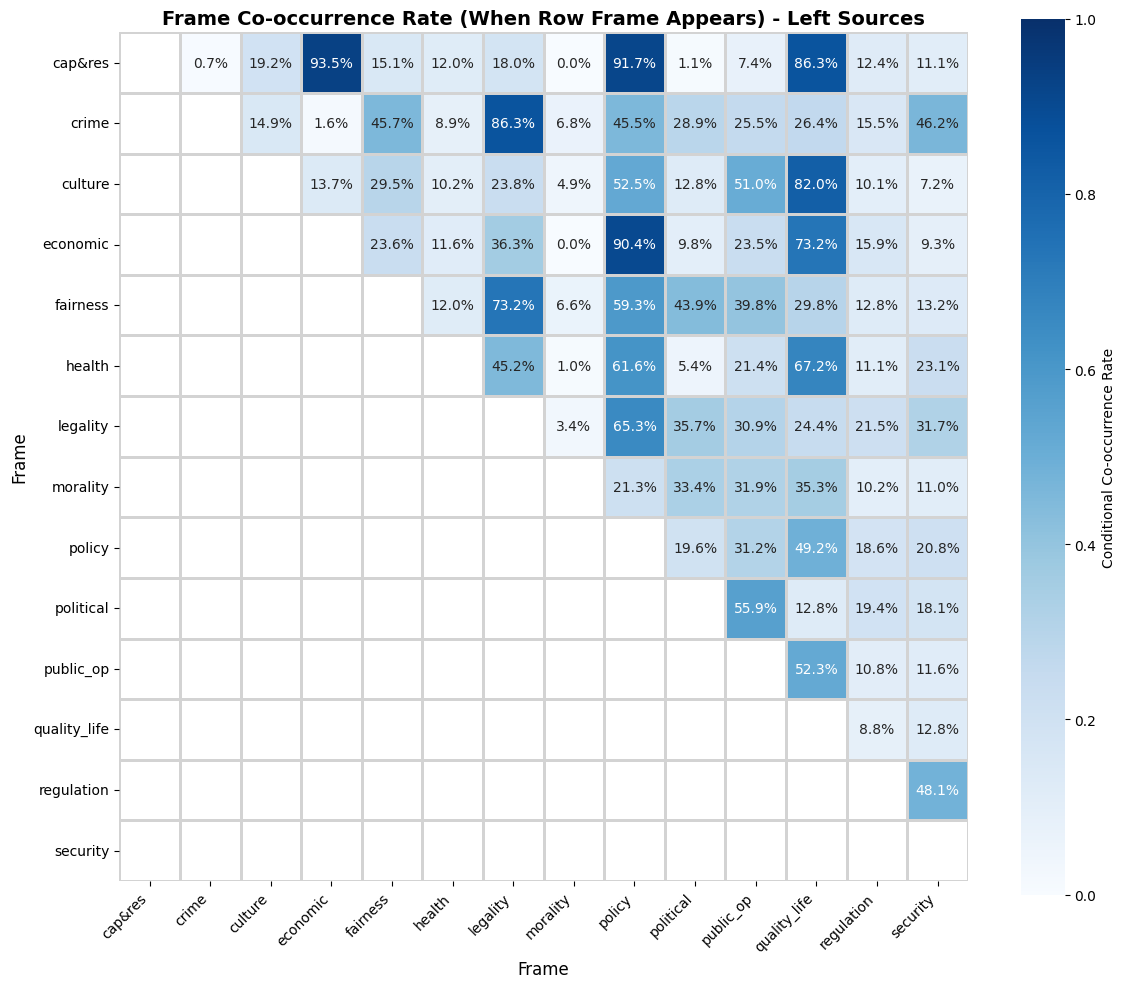

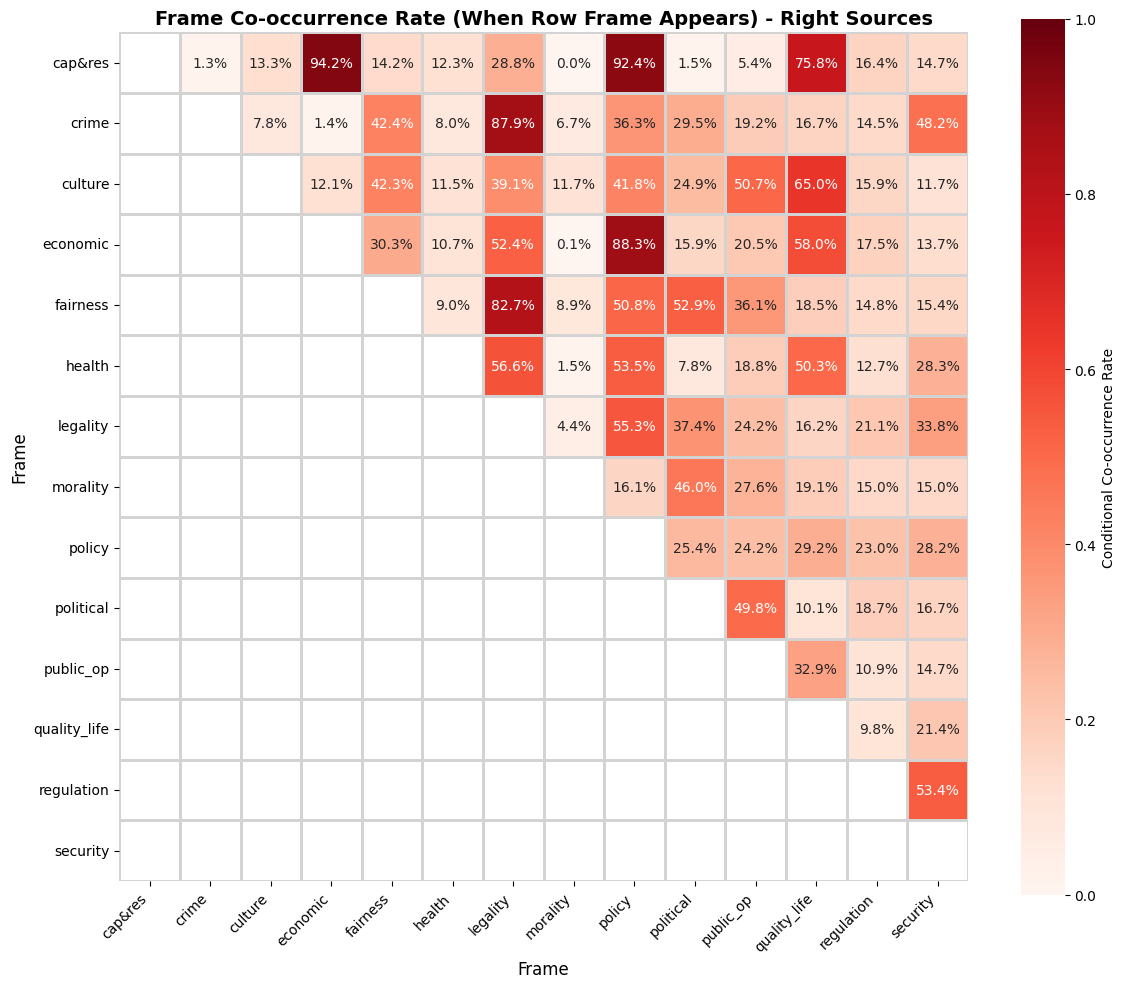

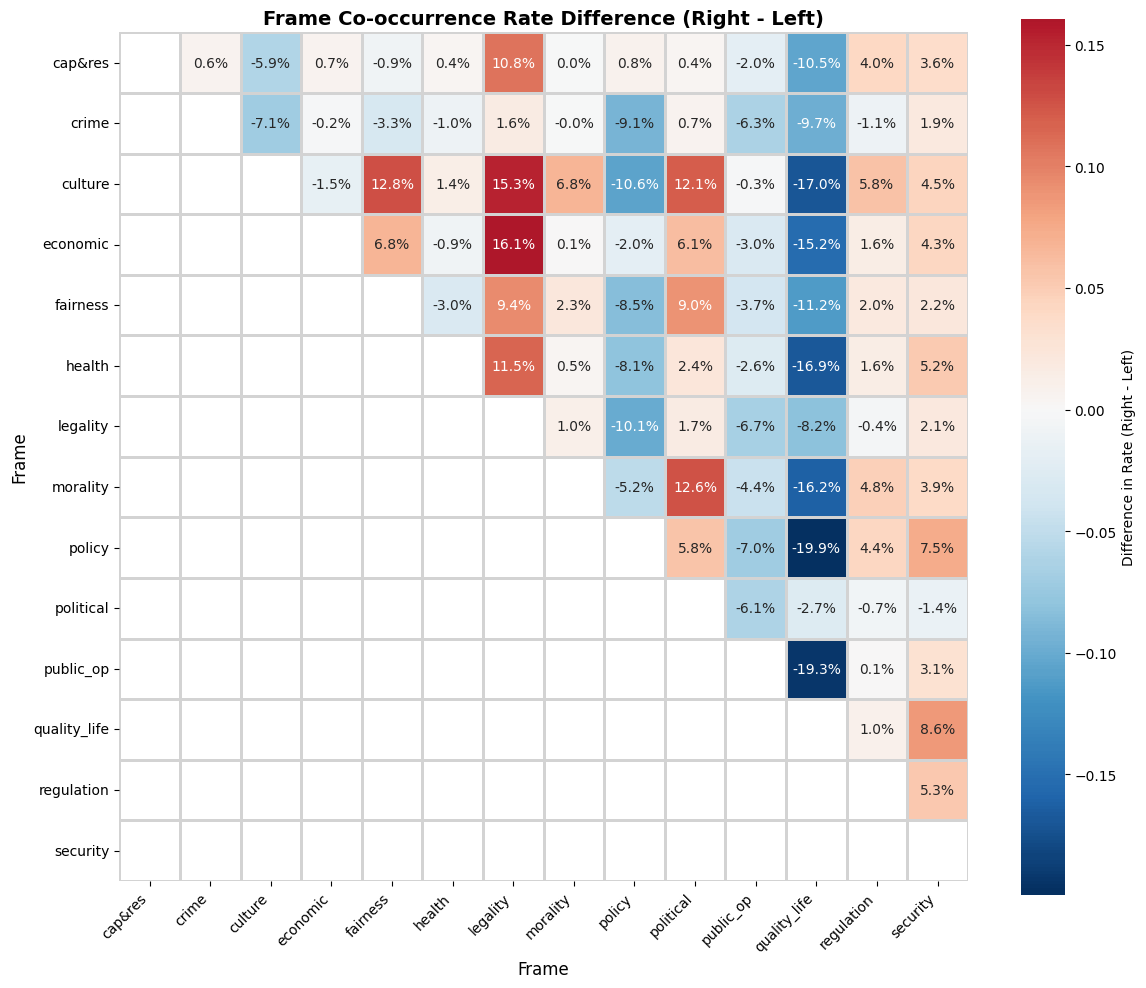

In [67]:
left_conditional = left_frame_cooccur.copy()
right_conditional = right_frame_cooccur.copy()

for i in range(len(ordered_frame_names)):
    if left_frame_cooccur.iloc[i, i] > 0:
        left_conditional.iloc[i, :] = left_frame_cooccur.iloc[i, :] / left_frame_cooccur.iloc[i, i]
    if right_frame_cooccur.iloc[i, i] > 0:
        right_conditional.iloc[i, :] = right_frame_cooccur.iloc[i, :] / right_frame_cooccur.iloc[i, i]

# Calculate difference
difference_conditional = right_conditional - left_conditional

# Mask for upper triangle AND diagonal
mask = np.tril(np.ones_like(left_conditional, dtype=bool), k=0)

# 1. LEFT - Blues (conditional)
plt.figure(figsize=(12, 10))
sns.heatmap(left_conditional, mask=mask, annot=True, fmt='.1%', cmap='Blues',
            vmin=0, vmax=1, cbar_kws={'label': 'Conditional Co-occurrence Rate'},
            linewidths=2, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate (When Row Frame Appears) - Left Sources', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. RIGHT - Reds (conditional)
plt.figure(figsize=(12, 10))
sns.heatmap(right_conditional, mask=mask, annot=True, fmt='.1%', cmap='Reds',
            vmin=0, vmax=1, cbar_kws={'label': 'Conditional Co-occurrence Rate'},
            linewidths=2, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate (When Row Frame Appears) - Right Sources', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. DIFFERENCE (Right - Left) - Blue-Red diverging (conditional)
plt.figure(figsize=(12, 10))
sns.heatmap(difference_conditional, mask=mask, annot=True, fmt='.1%', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference in Rate (Right - Left)'},
            linewidths=2, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate Difference (Right - Left)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Topic-Frame by Bias over Time

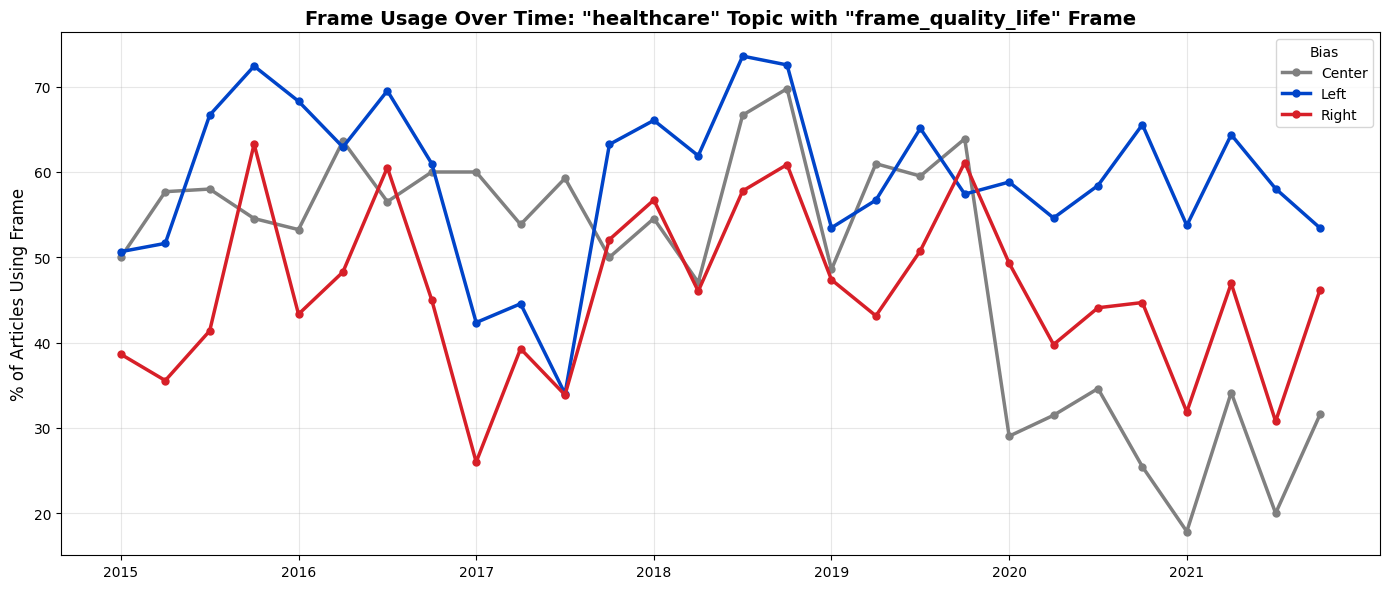

In [68]:
# Show the % a given topic uses a frame by bias over time, quarterly data

def plot_topic_frame_over_time(topic, frame, df):
    
    # Filter for the specific topic
    topic_df = df[df['topic_top1'] == topic].copy()
    
    if len(topic_df) == 0:
        print(f"No articles found for topic '{topic}'")
        return
    
    # Group by year_q and bias, calculate % using the frame
    results = []
    for (year_q, bias), group in topic_df.groupby(['quarter', 'bias_grouped']):
        total = len(group)
        frame_count = group[frame].sum()
        pct = frame_count / total if total > 0 else 0
        results.append({
            'quarter': year_q,
            'bias_grouped': bias,
            'percentage': pct * 100
        })
    
    results_df = pd.DataFrame(results)
    
    # Pivot for easier plotting
    pivot_df = results_df.pivot(index='quarter', columns='bias_grouped', values='percentage')
    
    # Sort by quarter
    pivot_df = pivot_df.sort_index()
    
    # Plot
    plt.figure(figsize=(14, 6))
    
    for bias in pivot_df.columns:
        if bias in color_map:
            plt.plot(range(len(pivot_df)), pivot_df[bias], 
                    label=bias, color=color_map[bias], 
                    linewidth=2.5, marker='o', markersize=5)
    
    plt.ylabel('% of Articles Using Frame', fontsize=12)
    plt.title(f'Frame Usage Over Time: "{topic}" Topic with "{frame}" Frame', 
              fontsize=14, fontweight='bold')
    plt.legend(title='Bias', loc='best')
    plt.grid(alpha=0.3)
    
    # Show only years on x-axis
    year_ticks = [i for i, label in enumerate(pivot_df.index) if label.endswith('Q1')]
    year_labels = [pivot_df.index[i][:4] for i in year_ticks]
    plt.xticks(year_ticks, year_labels)
    
    plt.tight_layout()
    plt.show()

# Usage example:
plot_topic_frame_over_time('healthcare', 'frame_quality_life', final_topic_frame_df) # shows divergence post-covid 

#### Frame Frequency by Source

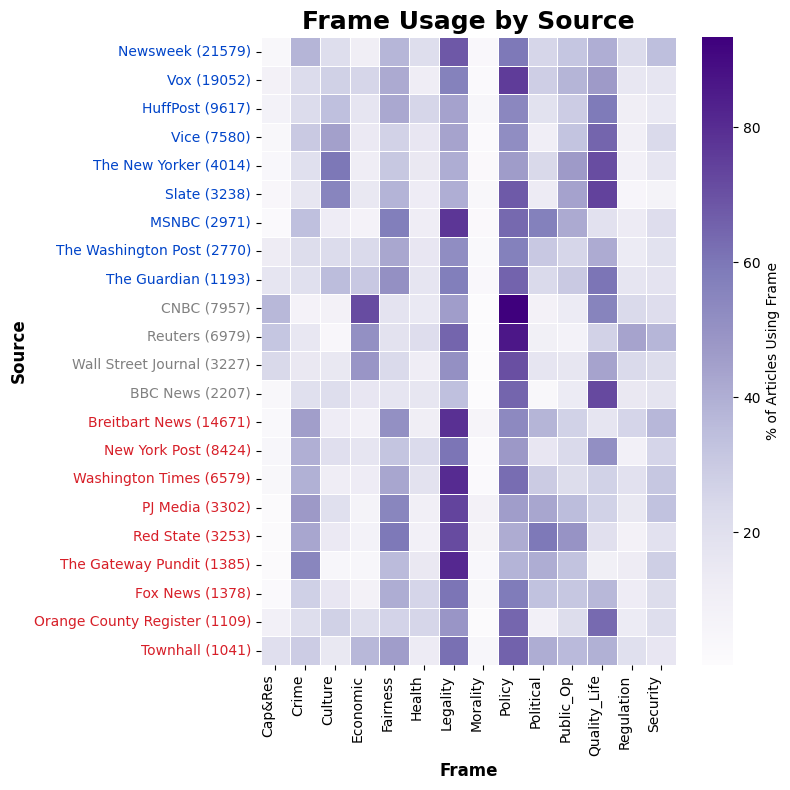

In [78]:
# by source vertically on y axis (color label by bias) heatmap of frame frequency

def plot_source_frame_heatmap_vert(df):
    
    # Get frame columns
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
    
    # Calculate frame usage by source
    source_frame_data = []
    for source in df['outlet_name'].unique():
        source_df = df[df['outlet_name'] == source]
        total = len(source_df)
        bias = source_df['bias_grouped'].iloc[0]
        
        row = {'outlet_name': source, 'bias_grouped': bias, 'total': total}
        for frame_col in frame_cols:
            frame_count = source_df[frame_col].sum()
            pct = (frame_count / total) * 100 if total > 0 else 0
            row[frame_col] = pct
        
        source_frame_data.append(row)
    
    source_frame_df = pd.DataFrame(source_frame_data)
    
    # Sort by bias (Left, Center, Right) then by total articles within bias
    bias_order = {'Left': 0, 'Center': 1, 'Right': 2}
    source_frame_df['bias_sort'] = source_frame_df['bias_grouped'].map(bias_order)
    source_frame_df = source_frame_df.sort_values(['bias_sort', 'total'], ascending=[True, False])
    source_frame_df = source_frame_df.drop('bias_sort', axis=1)
    
    heatmap_data = source_frame_df[frame_cols].values
    biases = source_frame_df['bias_grouped'].values

    # Show total articles in source labels
    sources = source_frame_df['outlet_name'].values
    sources_with_count = [f"{row['outlet_name']} ({row['total']})" 
                          for _, row in source_frame_df.iterrows()]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(8, 8))
    
    sns.heatmap(heatmap_data, 
                xticklabels=[clean_names.get(col, col.replace('frame_', '').title()) for col in frame_cols],
                yticklabels=sources_with_count, #can toggle to sources if don't want to show
                cmap='Purples',
                cbar_kws={'label': '% of Articles Using Frame'},
                linewidths=0.5,
                linecolor='white',
                ax=ax)
    
    # Color outlet labels by bias
    for i, (label, bias) in enumerate(zip(ax.get_yticklabels(), biases)):
        label.set_color(color_map[bias])
        #label.set_fontweight('bold')
    
    ax.set_xlabel('Frame', fontsize=12, fontweight='bold')
    ax.set_ylabel('Source', fontsize=12, fontweight='bold')
    ax.set_title('Frame Usage by Source', fontsize=18, fontweight='bold')
    
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_source_frame_heatmap_vert(final_topic_frame_df)

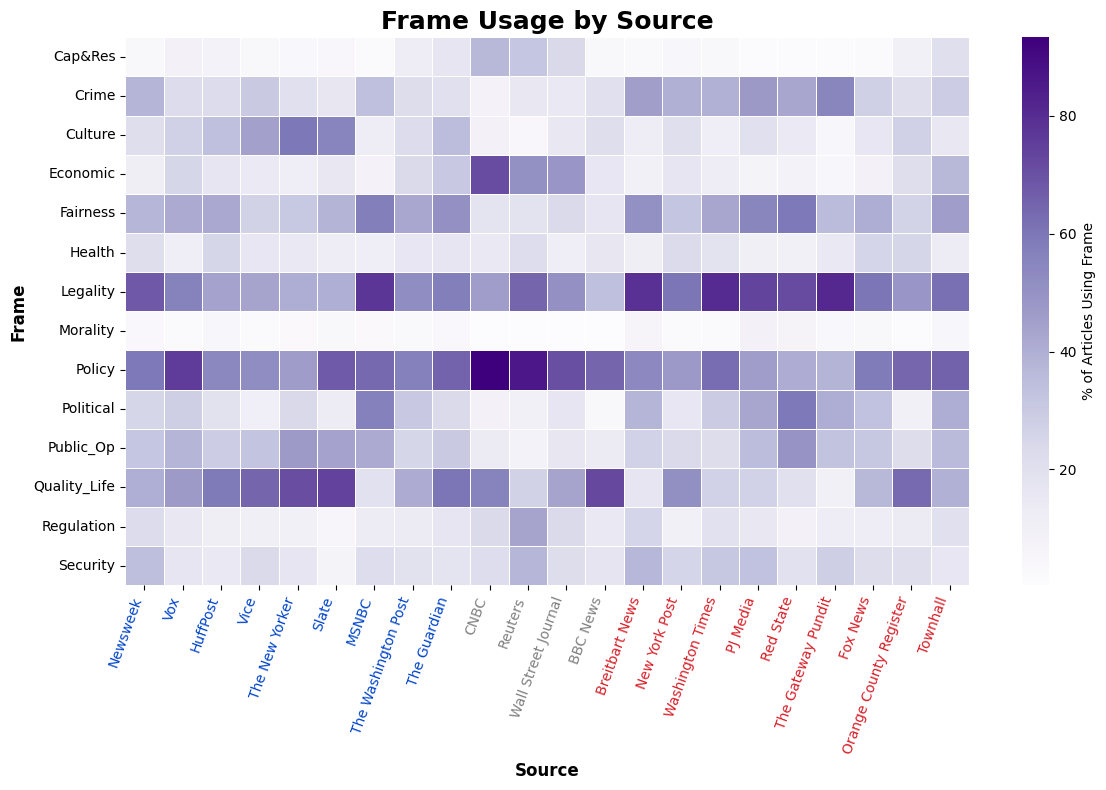

In [76]:
# Flip axes 

def plot_source_frame_heatmap_horiz(df):
    
    # Get frame columns
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
    
    # Calculate frame usage by source
    source_frame_data = []
    for source in df['outlet_name'].unique():
        source_df = df[df['outlet_name'] == source]
        total = len(source_df)
        bias = source_df['bias_grouped'].iloc[0]
        
        row = {'outlet_name': source, 'bias_grouped': bias, 'total': total}
        for frame_col in frame_cols:
            frame_count = source_df[frame_col].sum()
            pct = (frame_count / total) * 100 if total > 0 else 0
            row[frame_col] = pct
        
        source_frame_data.append(row)
    
    source_frame_df = pd.DataFrame(source_frame_data)
    
    # Sort by bias (Left, Center, Right) then by total articles within bias
    bias_order = {'Left': 0, 'Center': 1, 'Right': 2}
    source_frame_df['bias_sort'] = source_frame_df['bias_grouped'].map(bias_order)
    source_frame_df = source_frame_df.sort_values(['bias_sort', 'total'], ascending=[True, False])
    source_frame_df = source_frame_df.drop('bias_sort', axis=1)
    
    # Transpose the heatmap data
    heatmap_data = source_frame_df[frame_cols].values.T
    biases = source_frame_df['bias_grouped'].values
    sources = source_frame_df['outlet_name'].values
    sources_with_count = [f"{row['outlet_name']} ({row['total']})" 
                          for _, row in source_frame_df.iterrows()]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sns.heatmap(heatmap_data, 
                yticklabels=[clean_names.get(col, col.replace('frame_', '').title()) for col in frame_cols],
                xticklabels=sources,  #can toggle to sources_with_count if don't want to show # articles
                cmap='Purples',
                cbar_kws={'label': '% of Articles Using Frame'},
                linewidths=0.5,
                linecolor='white',
                ax=ax)
    
    # Color outlet labels by bias (now on x-axis)
    for i, (label, bias) in enumerate(zip(ax.get_xticklabels(), biases)):
        label.set_color(color_map[bias])
    
    ax.set_xlabel('Source', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frame', fontsize=12, fontweight='bold')
    ax.set_title('Frame Usage by Source', fontsize=18, fontweight='bold')
    
    plt.xticks(rotation=70, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_source_frame_heatmap_horiz(final_topic_frame_df)

#### Toggle Topics, frame rates by bias

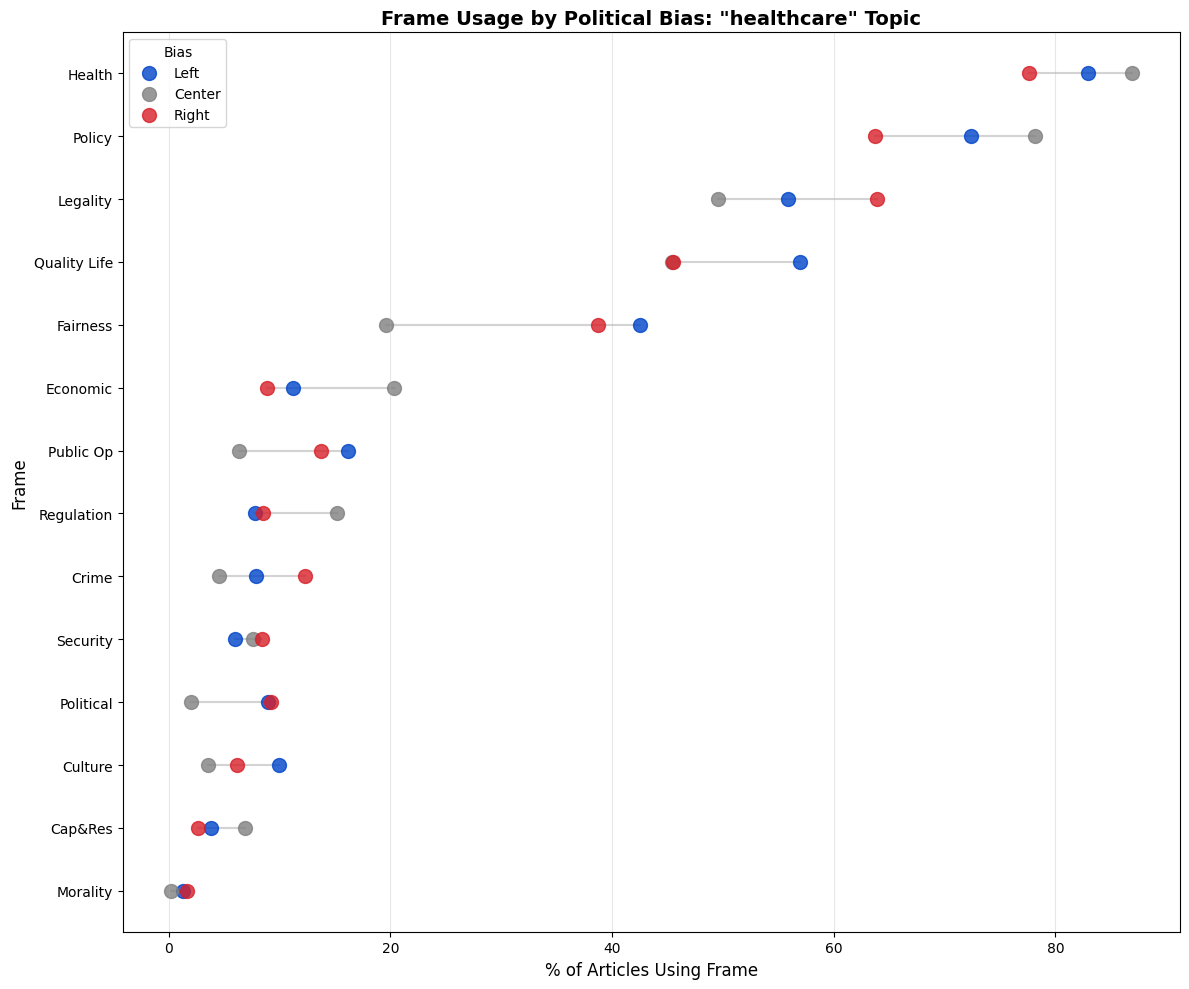

In [12]:
# select topic. shows frames for each of right/center/left by color as a line across x asxis, sorted top to bottom for most frequent frame

def plot_topic_frame_by_bias(topic, df):
    """
    Plot frame usage for a given topic across Left/Center/Right
    
    Parameters:
    topic (str): The topic to focus on
    df (pd.DataFrame): The dataframe with topic and frame data
    """
    
    # Filter for the specific topic
    topic_df = df[df['topic_top1'] == topic].copy()
    
    if len(topic_df) == 0:
        print(f"No articles found for topic '{topic}'")
        return
    
    # Get frame columns
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
    
    # Calculate percentage for each frame by bias
    results = []
    for bias in ['Left', 'Center', 'Right']:
        bias_df = topic_df[topic_df['bias_grouped'] == bias]
        total = len(bias_df)
        
        if total > 0:
            for frame_col in frame_cols:
                frame_count = bias_df[frame_col].sum()
                pct = (frame_count / total) * 100
                frame_name = frame_col.replace('frame_', '').replace('_', ' ').title()
                results.append({
                    'frame': frame_name,
                    'bias': bias,
                    'percentage': pct
                })
    
    results_df = pd.DataFrame(results)
    
    # Pivot for easier plotting
    pivot_df = results_df.pivot(index='frame', columns='bias', values='percentage')
    
    # Sort by total usage (sum across all biases)
    pivot_df['total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values('total', ascending=True)
    pivot_df = pivot_df.drop('total', axis=1)
    
    # Reorder columns to Left, Center, Right
    pivot_df = pivot_df[['Left', 'Center', 'Right']]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_positions = np.arange(len(pivot_df))

    # Draw horizontal lines connecting the three points for each frame
    for i, (idx, row) in enumerate(pivot_df.iterrows()):
        ax.plot([row['Left'], row['Center'], row['Right']], 
                [i, i, i], 
                color='lightgrey', linewidth=1.5, zorder=1)
    
    for bias, color in color_map.items():
        ax.scatter(pivot_df[bias], y_positions, 
                   s=100, label=bias, color=color, alpha=0.8)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(pivot_df.index)
    ax.set_xlabel('% of Articles Using Frame', fontsize=12)
    ax.set_ylabel('Frame', fontsize=12)
    ax.set_title(f'Frame Usage by Political Bias: "{topic}" Topic', 
                 fontsize=14, fontweight='bold')
    ax.legend(title='Bias', loc='best')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Usage:
plot_topic_frame_by_bias('healthcare', final_topic_frame_df)

### Interactivity

##### Topic-Frame Usage by Bias

In [ ]:
# Toggle topic and show sorted frame usage

def create_interactive_topic_frame_bias(df):
    
    # Get topics & frame columns
    topics = sorted(df['topic_top1'].unique())
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
        
    # Create figure
    fig = go.Figure()
    
    # Generate data for each topic
    for topic_idx, topic in enumerate(topics):
        topic_df = df[df['topic_top1'] == topic].copy()
        
        # Calculate percentage for each frame by bias
        results = []
        for bias in ['Left', 'Center', 'Right']:
            bias_df = topic_df[topic_df['bias_grouped'] == bias]
            total = len(bias_df)
            
            if total > 0:
                for frame_col in frame_cols:
                    frame_count = bias_df[frame_col].sum()
                    pct = (frame_count / total) * 100
                    frame_name = frame_col.replace('frame_', '').replace('_', ' ').title()
                    results.append({
                        'frame': frame_name,
                        'bias': bias,
                        'percentage': pct
                    })
        
        results_df = pd.DataFrame(results)
        pivot_df = results_df.pivot(index='frame', columns='bias', values='percentage')
        
        # Sort by total usage
        pivot_df['total'] = pivot_df.sum(axis=1)
        pivot_df = pivot_df.sort_values('total', ascending=True)
        pivot_df = pivot_df.drop('total', axis=1)
        
        # Reorder columns
        pivot_df = pivot_df[['Left', 'Center', 'Right']]
        
        # Add connecting lines for each frame
        for i, (frame, row) in enumerate(pivot_df.iterrows()):
            fig.add_trace(go.Scatter(
                x=[row['Left'], row['Center'], row['Right']],
                y=[frame, frame, frame],
                mode='lines',
                line=dict(color='lightgrey', width=2),
                showlegend=False,
                visible=(topic_idx == 0),
                hoverinfo='skip'
            ))
        
        # Add points for each bias
        for bias, color in color_map.items():
            fig.add_trace(go.Scatter(
                x=pivot_df[bias],
                y=pivot_df.index,
                mode='markers',
                name=bias,
                marker=dict(size=12, color=color),
                showlegend=(topic_idx == 0),
                visible=(topic_idx == 0),
                hovertemplate=f'<b>{bias}</b><br>%{{y}}<br>%{{x:.1f}}%<extra></extra>'
            ))
    
    # Create dropdown menu
    buttons = []
    n_traces_per_topic = len(frame_cols) + 3  # lines + 3 bias groups
    
    for topic_idx, topic in enumerate(topics):
        visible = [False] * len(fig.data)
        start_idx = topic_idx * n_traces_per_topic
        end_idx = start_idx + n_traces_per_topic
        
        for i in range(start_idx, end_idx):
            visible[i] = True
        
        buttons.append(dict(
            label=topic,
            method='update',
            args=[{'visible': visible},
                  {'title': f'Frame Usage by Political Bias: "{topic}" Topic'}]
        ))
    
    # Update layout
    fig.update_layout(
        updatemenus=[{
            'buttons': buttons,
            'direction': 'down',
            'showactive': True,
            'x': 0.8,
            'xanchor': 'center',
            'y': 1.125,
            'yanchor': 'top'
        }],
        title=f'Frame Usage by Political Bias: "{topics[0]}" Topic',
        xaxis_title='% of Articles Using Frame',
        yaxis_title='Frame',
        height=800,
        width=1000,
        hovermode='closest',
        plot_bgcolor='white',
        xaxis=dict(gridcolor='lightgrey', gridwidth=0.5),
        yaxis=dict(gridcolor='lightgrey', gridwidth=0.5)
    )
    
    fig.show()

# NOT ENDING UP USING IN BLOG POST
figN = create_interactive_topic_frame_bias(final_topic_frame_df)

##### Viz 1 - Frame Usage by News Outlet

In [132]:
# Add hover tool and interactivity to horizontal heatmap

def plot_source_frame_heatmap_horiz(df):
    
    # Get frame columns
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
    
    # Calculate frame usage by source
    source_frame_data = []
    for source in df['outlet_name'].unique():
        source_df = df[df['outlet_name'] == source]
        total = len(source_df)
        bias = source_df['bias_grouped'].iloc[0]
        
        row = {'outlet_name': source, 'bias_grouped': bias, 'total': total}
        for frame_col in frame_cols:
            frame_count = source_df[frame_col].sum()
            pct = (frame_count / total) * 100 if total > 0 else 0
            row[frame_col] = pct
        
        source_frame_data.append(row)
    
    source_frame_df = pd.DataFrame(source_frame_data)
    
    # Sort by bias (Left, Center, Right) then by total articles within bias
    bias_order = {'Left': 0, 'Center': 1, 'Right': 2}
    source_frame_df['bias_sort'] = source_frame_df['bias_grouped'].map(bias_order)
    source_frame_df = source_frame_df.sort_values(['bias_sort', 'total'], ascending=[True, False])
    source_frame_df = source_frame_df.drop('bias_sort', axis=1)
    
    # Transpose the heatmap data
    heatmap_data = source_frame_df[frame_cols].values.T[::-1]
    biases = source_frame_df['bias_grouped'].values
    sources = source_frame_df['outlet_name'].values
    sources_with_count = [f"{row['outlet_name']} ({row['total']})" 
                          for _, row in source_frame_df.iterrows()]
    
    # Show cleaned names
    #frame_labels = [clean_names.get(col, col.replace('frame_', '').title()) for col in frame_cols]
    frame_labels = [clean_names.get(col.replace('frame_', ''), col.replace('frame_', '').title()) for col in frame_cols][::-1]
    
    # Create custom hover text
    hover_text = []
    for i, frame in enumerate(frame_labels):
        row_text = []
        for j, source in enumerate(sources):
            row_text.append(f"Source: {source}<br>Frame: {frame}<br>Usage: {heatmap_data[i, j]:.1f}%")
        hover_text.append(row_text)
    
    # Create plotly heatmap
    fig = go.Figure(data=go.Heatmap(
        z=heatmap_data,
        x=sources,
        y=frame_labels,
        hovertext=hover_text,
        hoverinfo='text',
        colorscale='Purples',
        colorbar=dict(
        title=dict(
            text='% of Articles Using Frame',
            font=dict(size=12),
            side='right'),
        thickness=15
        )
    ))
    
    # Color x-axis labels by bias
    tickcolors = [color_map[bias] for bias in biases]
    
    fig.update_layout(
        # commenting out but leaving code below - find it sleeker without these visuals, accompanying write up will be clear

        #title=dict(text='Frame Usage by Source<', 
        #           font=dict(size=18),
        #           x=0.5,
        #           xanchor='center'
        #           ),
        xaxis=dict(
        #    title='Source',
            tickangle=-90, #can toggle for readability
        #    tickfont=dict(size=12)
        ),
        #yaxis=dict(
        #    title='Frame',
        #    tickfont=dict(size=12)
        #),
        width=900,
        height=500,
        margin=dict(t=50, l=50, r=50, b=100)
    )
    
    # Apply colors to x-axis tick labels
    fig.update_xaxes(
        tickvals=list(range(len(sources))),
        ticktext=[f"<span style='color:{color}'>{source}</span>" 
                  for source, color in zip(sources, tickcolors)]
    )

    # differentiate between sections of bias
    fig.add_vline(x=-0.5, line_width=2, line_color="black") 
    fig.add_vline(x=21.5, line_width=2, line_color="black")
    fig.add_vline(x=8.5, line_width=2, line_color="black") 
    fig.add_vline(x=12.5, line_width=2, line_color="black")

    fig.add_hline(y=-0.5, line_width=2, line_color="black") 
    fig.add_hline(y=13.5, line_width=2, line_color="black")

    # add small legend for bias colors
    fig.add_annotation(
        x=0, y=-0.5,
        xref='paper', yref='paper',
        text='<span style="color:#0044C9">Left</span>   <span style="color:#808080">Center</span>   <span style="color:#D71F28">Right</span>',
        showarrow=False,
        font=dict(size=12),
        align='left',
        bgcolor='white',
        bordercolor='black',
        borderwidth=1,
        borderpad=5
    )

    return fig

fig = plot_source_frame_heatmap_horiz(final_topic_frame_df)
fig.show()

##### Viz 2 - Topic-Frame Usage By Bias Over Time

In [56]:
# Show frame usage for a given topic, with toggling between all topics and frames

def create_interactive_topic_frame_time(df):

    # Get topics and frames, add "All Topics" option
    topics = ['All Topics'] + sorted(df['topic_top1'].unique())
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
    
    # Clean frame names for display
    frame_display_names = {}
    for col in frame_cols:
        clean_name = col.replace('frame_', '').replace('cap&res', 'Capacity & Resources').replace('public_op', 'Public Opinion').replace('quality_life', 'Quality of Life').replace('_', ' ').title()
        frame_display_names[col] = clean_name
    
    # Create figure
    fig = go.Figure()
    
    # Generate data for each topic-frame combination
    trace_idx = 0
    for topic in topics:
        for frame_col in frame_cols:

            # select subset of df 
            if topic == 'All Topics':
                topic_df = df.copy()
            else:
                topic_df = df[df['topic_top1'] == topic].copy()
            if len(topic_df) == 0:
                continue
            
            # Group by quarter and bias
            results = []
            for (quarter, bias), group in topic_df.groupby(['quarter', 'bias_grouped']):
                total = len(group)
                frame_count = group[frame_col].sum()
                pct = frame_count / total if total > 0 else 0
                results.append({
                    'quarter': quarter,
                    'bias_grouped': bias,
                    'percentage': pct * 100
                })
            
            results_df = pd.DataFrame(results)
            pivot_df = results_df.pivot(index='quarter', columns='bias_grouped', values='percentage')
            pivot_df = pivot_df.sort_index()

            # Add traces for each bias
            for bias in ['Left', 'Center', 'Right']:

                # Adjusted labels for hover to have Q#_Yr format - Claude helped here!
                quarter_labels = [f"Q{str(q)[-1]} {str(q)[:4]}" for q in pivot_df.index]
                
                fig.add_trace(go.Scatter(
                    x=pivot_df.index,
                    y=pivot_df[bias],
                    customdata=quarter_labels,  # format labels go here to fit in hovertemplate
                    mode='lines+markers',
                    name=bias,
                    line=dict(color=color_map[bias], width=2.5),
                    marker=dict(size=6),
                    visible=(trace_idx == 1),
                    showlegend=True,
                    hovertemplate=f'<b>{bias}</b><br>%{{customdata}}<br>%{{y:.1f}}%<extra></extra>'
                ))
            
            trace_idx += 1
    
    # Create dropdown menus
    
    # Topic dropdown
    topic_buttons = []
    for topic_idx, topic in enumerate(topics):
        visible = [False] * len(fig.data)
        # Show first frame for this topic (3 traces: Left, Center, Right)
        start_idx = topic_idx * len(frame_cols) * 3
        for i in range(start_idx, start_idx + 3):
            if i < len(fig.data):
                visible[i] = True
        
        topic_buttons.append(dict(
            label=topic,
            method='update',
        args=[{'visible': visible},
                {'title.text': f'Frequency of "{frame_display_names[frame_cols[0]]}" framing in articles of topic: "{topic}"',
                'title.x': 0.4,
                'title.xanchor': 'left',
                'title.y': 0.925,
                'title.yanchor': 'top'}]
        ))

    # Frame dropdown
    frame_buttons = []
    for frame_idx, frame_col in enumerate(frame_cols):
        visible = [False] * len(fig.data)
        # Show first topic for this frame (3 traces: Left, Center, Right)
        start_idx = frame_idx * 3
        for i in range(start_idx, start_idx + 3):
            if i < len(fig.data):
                visible[i] = True
        
        frame_buttons.append(dict(
            label=frame_display_names[frame_col],
            method='update',
            args=[{'visible': visible},
                {'title.text': f'Frequency of "{frame_display_names[frame_col]}" framing in articles of topic: "{topics[0]}"',
                'title.x': 0.4,
                'title.xanchor': 'left',
                'title.y': 0.925,
                'title.yanchor': 'top'}]
        ))
        
    # ticks for years on x-axis
    all_quarters = sorted(df['quarter'].unique())
    all_quarters_str = [str(q) for q in all_quarters]
    year_ticks = [q for q in all_quarters_str if q.endswith('Q1')]
    year_labels = [q[:4] for q in year_ticks]

    # Update layout
    fig.update_layout(
    updatemenus=[
        {
            'buttons': topic_buttons,
            'direction': 'down',
            'showactive': True,
            'x': 0.0,
            'xanchor': 'left',
            'y': 1.15,
            'yanchor': 'top',
            'active': 0, # show All Topics first
            'bgcolor': 'white',
            'bordercolor': 'lightgrey',
            'borderwidth': 1
        },
        {
            'buttons': frame_buttons,
            'direction': 'down',
            'showactive': True,
            'x': 0.2,
            'xanchor': 'left',
            'y': 1.15,
            'yanchor': 'top',
            'active': 1, # show Crime first
            'bgcolor': 'white',
            'bordercolor': 'lightgrey',
            'borderwidth': 1
        }
    ],
    annotations=[
        dict(text="Topic:", x=0.0, xref="paper", xanchor='left', y=1.2, yref="paper", showarrow=False, font=dict(size=11)),
        dict(text="Frame:", x=0.2, xref="paper", xanchor='left', y=1.2, yref="paper", showarrow=False, font=dict(size=11)),
    ],
    title={'text': f'Frequency of "{frame_display_names[frame_cols[1]]}" framing in articles of topic: "{topics[0]}"', 
       'x': 0.4, 'xanchor': 'left', 'y': 0.925, 'yanchor': 'top'},
    height=600,
    width=1200,
    hovermode='closest',
    plot_bgcolor='white', #Change for MEDIUM.COM, dark mode, any further uses
    xaxis=dict(gridcolor='lightgrey', gridwidth=0.5, tickmode='array', tickvals=year_ticks, ticktext=year_labels),
    yaxis=dict(gridcolor='lightgrey', gridwidth=0.5),
    margin=dict(t=100)
)
    return fig

fig2 = create_interactive_topic_frame_time(final_topic_frame_df)
fig2.show()



##### Expand Viz 2 With JS to Correct Toggling

In [ ]:
# previous viz has issues maintaining state of one dropdown when toggling the other, resetting with javascript to HTML file that can run both. Claude helped here!

def create_interactive_topic_frame_time(df, color_map):

    # Get topics and frames, add "All Topics" option
    topics = ['All Topics'] + sorted(df['topic_top1'].unique())
    frame_cols = [col for col in df.columns if col.startswith('frame_')]
    
    # Clean frame names for display
    frame_display_names = {}
    for col in frame_cols:
        clean_name = col.replace('frame_', '').replace('cap&res', 'Capacity & Resources').replace('public_op', 'Public Opinion').replace('quality_life', 'Quality of Life').replace('_', ' ').title()
        frame_display_names[col] = clean_name
    
    # Create figure
    fig = go.Figure()
    
    # Build all combinations and track trace indices
    combinations = []  # list of (topic, frame_col) tuples
    default_combo_idx = 1  # setting to Topic 0 (All Topics), Frame 1 (Crime) as a good example/starting off point for viewers
    
    for topic in topics:
        for frame_col in frame_cols:
            
            # select subset of df 
            if topic == 'All Topics':
                topic_df = df.copy()
            else:
                topic_df = df[df['topic_top1'] == topic].copy()
            if len(topic_df) == 0:
                continue
            
            combinations.append((topic, frame_col))
            
            # Group by quarter and bias
            results = []
            for (quarter, bias), group in topic_df.groupby(['quarter', 'bias_grouped']):
                total = len(group)
                frame_count = group[frame_col].sum()
                pct = frame_count / total if total > 0 else 0
                results.append({
                    'quarter': quarter,
                    'bias_grouped': bias,
                    'percentage': pct * 100
                })
            
            results_df = pd.DataFrame(results)
            pivot_df = results_df.pivot(index='quarter', columns='bias_grouped', values='percentage')
            pivot_df = pivot_df.sort_index()

            # Add traces for each bias (3 traces per combination)
            combo_idx = len(combinations) - 1
            for bias in ['Left', 'Center', 'Right']:
                quarter_labels = [f"Q{str(q)[-1]} {str(q)[:4]}" for q in pivot_df.index]
                
                fig.add_trace(go.Scatter(
                    x=pivot_df.index,
                    y=pivot_df[bias],
                    customdata=quarter_labels,
                    mode='lines+markers',
                    name=bias,
                    line=dict(color=color_map[bias], width=2.5),
                    marker=dict(size=6),
                    visible=(combo_idx == default_combo_idx),  # set to combo specified above 
                    showlegend=True,
                    hovertemplate=f'<b>{bias}</b><br>%{{customdata}}<br>%{{y:.1f}}%<extra></extra>'
                ))
    
    # Create single combined dropdown (will be hidden via CSS)
    buttons = []
    for combo_idx, (topic, frame_col) in enumerate(combinations):
        visible = [False] * len(fig.data)
        start_idx = combo_idx * 3
        for i in range(start_idx, start_idx + 3):
            visible[i] = True
        
        label = f"{topic} × {frame_display_names[frame_col]}"
        buttons.append(dict(
            label=label,
            method='update',
            args=[{'visible': visible},
                  {'title.text': f'Frequency of "{frame_display_names[frame_col]}" framing in articles of topic: "{topic}"',
                   'title.x': 0.5,
                   'title.xanchor': 'center',
                   'title.y': 0.925,
                   'title.yanchor': 'top'}]
        ))
        
    # ticks for years on x-axis
    all_quarters = sorted(df['quarter'].unique())
    all_quarters_str = [str(q) for q in all_quarters]
    year_ticks = [q for q in all_quarters_str if q.endswith('Q1')]
    year_labels = [q[:4] for q in year_ticks]

    default_topic, default_frame = combinations[default_combo_idx]

    # Update layout - keep dropdown in normal position, hide it with CSS    
    fig.update_layout(
        updatemenus=[
            {
                'buttons': buttons,
                'direction': 'down',
                'showactive': True,
                'x': 0.0,
                'xanchor': 'left',
                'y': 1.15,
                'yanchor': 'top',
                'active': default_combo_idx, # fit to combination chosen above
                'bgcolor': 'white',
                'bordercolor': 'lightgrey',
                'borderwidth': 1,
                'visible': False  # hide the plotly dropdown
            }
        ],
        #title={'text': f'Frequency of "{frame_display_names[combinations[0][1]]}" framing in articles of topic: "{combinations[0][0]}"', 
        #       'x': 0.5, 'xanchor': 'center', 'y': 0.925, 'yanchor': 'top'},
        title={'text': f'Frequency of "{frame_display_names[default_frame]}" framing in articles of topic: "{default_topic}"'},
        height=600,
        width=1200,
        hovermode='closest',
        plot_bgcolor='white',
        xaxis=dict(gridcolor='lightgrey', gridwidth=0.5, tickmode='array', tickvals=year_ticks, ticktext=year_labels),
        yaxis=dict(gridcolor='lightgrey', gridwidth=0.5),
        margin=dict(t=100)
    )
    
    return fig, topics, frame_cols, frame_display_names, combinations


def save_with_custom_dropdowns(fig, topics, frame_cols, frame_display_names, filename='topic_frame_interactive.html'):
    """Save the figure with custom HTML/JS dropdowns"""
    
    # Get the base HTML from plotly
    html_str = fig.to_html(include_plotlyjs=True, full_html=True)
    
    # Build topic options
    topic_options = '\n'.join([f'<option value="{i}">{t}</option>' for i, t in enumerate(topics)])
    
    # Build frame options
    #frame_options = '\n'.join([f'<option value="{i}">{frame_display_names[fc]}</option>' for i, fc in enumerate(frame_cols)])
    frame_options = '\n'.join([f'<option value="{i}"{" selected" if i == 1 else ""}>{frame_display_names[fc]}</option>' for i, fc in enumerate(frame_cols)])
    
    num_frames = len(frame_cols)
    
    # Custom CSS and HTML for dropdowns
    custom_controls = f'''
    <style>
        .custom-controls {{
            font-family: Arial, sans-serif;
            margin-bottom: 10px;
            display: flex;
            gap: 20px;
            align-items: center;
        }}
        .control-group {{
            display: flex;
            flex-direction: column;
            gap: 4px;
        }}
        .control-group label {{
            font-size: 12px;
            font-weight: bold;
            color: #333;
        }}
        .control-group select {{
            padding: 6px 12px;
            font-size: 14px;
            border: 1px solid lightgrey;
            border-radius: 4px;
            background: white;
            cursor: pointer;
            min-width: 180px;
        }}
        .control-group select:hover {{
            border-color: #999;
        }}
    </style>
    
    <div class="custom-controls">
        <div class="control-group">
            <label>Topic:</label>
            <select id="topic-select" onchange="updateChart()">
                {topic_options}
            </select>
        </div>
        <div class="control-group">
            <label>Frame:</label>
            <select id="frame-select" onchange="updateChart()">
                {frame_options}
            </select>
        </div>
    </div>
    
    <script>
        function updateChart() {{
            var topicIdx = parseInt(document.getElementById('topic-select').value);
            var frameIdx = parseInt(document.getElementById('frame-select').value);
            var numFrames = {num_frames};
            
            // Calculate combined index: topic * numFrames + frame
            var comboIdx = topicIdx * numFrames + frameIdx;
            
            // Get the plotly graph div
            var graphDiv = document.querySelector('.plotly-graph-div');
            
            // Get the menu buttons and simulate click
            var menuButtons = graphDiv._fullLayout.updatemenus[0].buttons;
            if (comboIdx < menuButtons.length) {{
                var button = menuButtons[comboIdx];
                Plotly.update(graphDiv, button.args[0], button.args[1]);
            }}
        }}
    </script>
    '''
    
    # Insert custom controls right after <body>
    html_str = html_str.replace('<body>', '<body>\n' + custom_controls)
    
    # Save to file
    with open(filename, 'w') as f:
        f.write(html_str)
    
    print(f"Saved to {filename}")
    return filename

Saved to topic_frame_interactive.html


'topic_frame_interactive.html'

### Output & Push to Github Pages

In [133]:
# To save for GitHub Pages:

fig1 = plot_source_frame_heatmap_horiz(final_topic_frame_df)
fig1.write_html('source_frame_heatmap_interactive.html')

fig2, topics, frame_cols, frame_display_names, combinations = create_interactive_topic_frame_time(final_topic_frame_df, color_map)
save_with_custom_dropdowns(fig2, topics, frame_cols, frame_display_names, 'topic_frame_interactive.html')

Saved to topic_frame_interactive.html


'topic_frame_interactive.html'